# Knowledge Localization

**Survey Reference:** Section 12.2 - Knowledge Localization: Where Is Information Stored?


This notebook demonstrates **causal tracing**, a technique for localizing where factual knowledge is stored in transformer models. The method was introduced in "Locating and Editing Factual Associations in GPT".

Process:
1. **Corrupt** the input by adding noise to subject tokens
2. **Restore** individual activation at different layers and token positions
3. **Measure** which restorations recover the model's ability to complete factual prompts

In [1]:
import os
import re
import json
import numpy as np
import torch
from collections import defaultdict
from matplotlib import pyplot as plt
import seaborn as sns

from transformers import AutoModelForCausalLM, AutoTokenizer

# Disable gradient computation for efficiency
torch.set_grad_enabled(False)

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


We'll use GPT-2 XL for this demonstration. The technique works with any transformer model.

In [2]:
class ModelAndTokenizer:
    def __init__(self, model_name, torch_dtype=None, low_cpu_mem_usage=False):
        self.model_name = model_name
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForCausalLM.from_pretrained(
            model_name, 
            torch_dtype=torch_dtype,
            low_cpu_mem_usage=low_cpu_mem_usage
        )
        self.model.to(device)
        self.model.eval()
        
        # Count layers
        if hasattr(self.model, 'transformer'):  # GPT-2 style
            self.num_layers = len(self.model.transformer.h)
        elif hasattr(self.model, 'model') and hasattr(self.model.model, 'layers'):  # Llama style
            self.num_layers = len(self.model.model.layers)
        else:
            raise ValueError("Unknown model architecture")
    

model_name = "gpt2-medium"
mt = ModelAndTokenizer(model_name)

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
def layername(model, num, kind=None):
    """
    Get the name of a specific layer in the model.
    
    Args:
        model: The transformer model
        num: Layer number
        kind: Type of layer ('embed', 'attn', 'mlp', or None for residual)
    """
    if hasattr(model, 'transformer'):  # GPT-2 style
        if kind == 'embed':
            return 'transformer.wte'
        if kind == 'attn':
            return f'transformer.h.{num}.attn'
        if kind == 'mlp':
            return f'transformer.h.{num}.mlp'
        return f'transformer.h.{num}'
    elif hasattr(model, 'model'):  # Llama style
        if kind == 'embed':
            return 'model.embed_tokens'
        if kind == 'attn':
            return f'model.layers.{num}.self_attn'
        if kind == 'mlp':
            return f'model.layers.{num}.mlp'
        return f'model.layers.{num}'
    else:
        raise ValueError("Unknown model architecture")


def make_inputs(tokenizer, prompts, device="cuda"):
    """
    Prepare inputs for the model from a list of prompts.
    """
    token_lists = [tokenizer.encode(p) for p in prompts]
    maxlen = max(len(t) for t in token_lists)
    
    # Pad if necessary
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id
    
    input_ids = [[tokenizer.pad_token_id] * (maxlen - len(t)) + t for t in token_lists]
    attention_mask = [[0] * (maxlen - len(t)) + [1] * len(t) for t in token_lists]
    
    return {
        'input_ids': torch.tensor(input_ids).to(device),
        'attention_mask': torch.tensor(attention_mask).to(device)
    }


def decode_tokens(tokenizer, token_array):
    """Decode token IDs to strings."""
    if len(token_array.shape) == 0:
        token_array = token_array.unsqueeze(0)
    return [tokenizer.decode([t]) for t in token_array]


def find_token_range(tokenizer, token_array, substring):
    """
    Find the token range corresponding to a substring in the prompt.
    """
    toks = decode_tokens(tokenizer, token_array)
    whole_string = "".join(toks)
    
    # Find substring position
    char_loc = whole_string.index(substring)
    
    # Convert to token positions
    loc = 0
    tok_start = None
    tok_end = None
    
    for i, t in enumerate(toks):
        if tok_start is None and loc >= char_loc:
            tok_start = i
        if tok_end is None and loc >= char_loc + len(substring):
            tok_end = i
            break
        loc += len(t)
    
    if tok_end is None:
        tok_end = len(toks)
    
    return (tok_start, tok_end)


def predict_from_input(model, inp):
    """
    Get model predictions from prepared inputs.
    """
    with torch.no_grad():
        out = model(**inp)["logits"]
    probs = torch.softmax(out[:, -1], dim=1)
    p, preds = torch.max(probs, dim=1)
    return preds, p


def predict_token(mt, prompts, return_p=False):
    """
    Predict next token for given prompts.
    """
    inp = make_inputs(mt.tokenizer, prompts, device)
    preds, p = predict_from_input(mt.model, inp)
    result = [mt.tokenizer.decode(c) for c in preds]
    if return_p:
        result = (result, p)
    return result


# predictions = predict_token(
#     mt,
#     ["The Eiffel Tower is in the city of",
#      "Albert Einstein was a"],
#     return_p=True
# )
# print("Predictions:", predictions[0])
# print("Probabilities:", predictions[1])

We corrupt inputs by adding Gaussian noise to embeddings. The noise level is calibrated to 3× the standard deviation of the model's embeddings.

In [4]:
def collect_embedding_std(mt, subjects):
    """
    Compute the standard deviation of embeddings for given subjects.
    This is used to calibrate the noise level.
    """
    alldata = []
    embed_layer = layername(mt.model, 0, "embed")
    
    # Get the embedding layer module
    module = mt.model
    for part in embed_layer.split('.'):
        module = getattr(module, part)
    
    for s in subjects:
        inp = make_inputs(mt.tokenizer, [s], device)
        with torch.no_grad():
            embeddings = module(inp['input_ids'])
            alldata.append(embeddings[0])
    
    alldata = torch.cat(alldata)
    noise_level = alldata.std().item()
    return noise_level


# Sample subjects to compute noise level
sample_subjects = [
    "Eiffel Tower",
    "Albert Einstein",
    "Mona Lisa",
    "Tokyo",
    "William Shakespeare"
]

noise_level = 3 * collect_embedding_std(mt, sample_subjects)
print(f"Using noise level: {noise_level:.4f}")

Using noise level: 0.3349



The `trace_with_patch` function implements the double-intervention strategy:
1. **Corrupt** the input by adding noise to subject token embeddings
2. **Restore** specific hidden states from the clean run
3. **Measure** the recovery in output probability

In [5]:
def trace_with_patch(
    model,
    inp,
    states_to_patch,  # List of (token_idx, layer_name) to restore
    answer_t,  # Expected answer token
    tokens_to_mix,  # Range (begin, end) to corrupt
    noise=0.1,
):
    """
    Run causal tracing with corruption and restoration.
    
    The batch should have:
    - Element 0: clean run (no corruption)
    - Elements 1+: corrupted runs
    
    We measure how restoring specific hidden states helps recover the output.
    """
    prng = np.random.RandomState(1)  # For reproducibility
    
    # Organize states to patch by layer
    patch_spec = defaultdict(list)
    for token_idx, layer in states_to_patch:
        patch_spec[layer].append(token_idx)
    
    embed_layername = layername(model, 0, "embed")
    
    def untuple(x):
        """Extract tensor from tuple if needed."""
        return x[0] if isinstance(x, tuple) else x
    
    # Store clean activations
    clean_activations = {}
    
    # Define intervention function
    def patch_rep(module, input, output):
        layer_name = None
        # Find which layer this is
        for name, mod in model.named_modules():
            if mod is module:
                layer_name = name
                break
        
        if layer_name is None:
            return output
        
        x = output
        
        # Corrupt embeddings
        if layer_name == embed_layername:
            if tokens_to_mix is not None:
                b, e = tokens_to_mix
                corruption = noise * torch.from_numpy(
                    prng.randn(x.shape[0] - 1, e - b, x.shape[2])
                ).to(x.device)
                x = x.clone()
                x[1:, b:e] += corruption
            # Store clean activation
            clean_activations[layer_name] = x[0:1].clone()
            return x
        
        # Restore hidden states
        if layer_name in patch_spec:
            x = untuple(x)
            x = x.clone()
            h = x
            
            # If we haven't seen the clean run yet, store it
            if layer_name not in clean_activations:
                clean_activations[layer_name] = h[0:1].clone()
            
            # Restore tokens from clean run
            for token_idx in patch_spec[layer_name]:
                if layer_name in clean_activations:
                    h[1:, token_idx] = clean_activations[layer_name][0, token_idx]
            
            # Return in same format as input
            if isinstance(output, tuple):
                return (h,) + output[1:]
            else:
                return h
        
        # Store clean activations for this layer
        if layer_name not in clean_activations:
            h = untuple(output)
            clean_activations[layer_name] = h[0:1].clone()
        
        return output
    
    # Register hooks
    hooks = []
    for name, module in model.named_modules():
        if name == embed_layername or name in patch_spec:
            hook = module.register_forward_hook(patch_rep)
            hooks.append(hook)
    
    try:
        with torch.no_grad():
            outputs = model(**inp)
        
        # Compute probability of answer token
        logits = outputs.logits[1:, -1, :]  # Skip clean run
        probs = torch.softmax(logits, dim=1)
        answer_prob = probs[:, answer_t].mean()
        
        return answer_prob
    
    finally:
        # Remove hooks
        for hook in hooks:
            hook.remove()

Now we scan every (token, layer) position to see which restorations have the biggest effect.

In [6]:
def trace_important_states(model, num_layers, inp, e_range, answer_t, noise=0.1):
    """
    Trace the importance of each hidden state by restoring it individually.
    
    Returns a tensor of shape (num_tokens, num_layers) with restoration effects.
    """
    ntoks = inp["input_ids"].shape[1]
    table = []
    
    for token_idx in range(ntoks):
        row = []
        for layer in range(num_layers):
            layer_name = layername(model, layer)
            r = trace_with_patch(
                model,
                inp,
                [(token_idx, layer_name)],
                answer_t,
                tokens_to_mix=e_range,
                noise=noise,
            )
            row.append(r)
        table.append(torch.stack(row))
    
    return torch.stack(table)


def trace_important_window(
    model, num_layers, inp, e_range, answer_t, kind, window=10, noise=0.1
):
    """
    Trace importance of MLP or attention blocks by restoring windows of layers.
    
    Since MLP and attention make small residual contributions, we need to
    restore several layers at once to see their effect.
    """
    ntoks = inp["input_ids"].shape[1]
    table = []
    
    for token_idx in range(ntoks):
        row = []
        for layer in range(num_layers):
            # Create a window of layers around the current layer
            window_start = max(0, layer - window // 2)
            window_end = min(num_layers, layer + (window + 1) // 2)
            
            layerlist = [
                (token_idx, layername(model, L, kind))
                for L in range(window_start, window_end)
            ]
            
            r = trace_with_patch(
                model, inp, layerlist, answer_t, tokens_to_mix=e_range, noise=noise
            )
            row.append(r)
        table.append(torch.stack(row))
    
    return torch.stack(table)

In [7]:
def calculate_hidden_flow(
    mt, prompt, subject, samples=10, noise=0.1, window=10, kind=None
):
    """
    Run causal tracing over every token/layer combination.
    
    Args:
        mt: ModelAndTokenizer instance
        prompt: The factual prompt to trace
        subject: The subject entity in the prompt
        samples: Number of corrupted samples to average over
        noise: Noise level for corruption
        window: Window size for MLP/attention tracing
        kind: None for residual stream, 'mlp' or 'attn' for specific components
    
    Returns:
        Dictionary with tracing results including scores matrix
    """
    # Prepare inputs (1 clean + N corrupted)
    inp = make_inputs(mt.tokenizer, [prompt] * (samples + 1), device)
    
    # Get baseline prediction
    with torch.no_grad():
        answer_t, base_score = predict_from_input(mt.model, inp)
        answer_t = answer_t[0]
        base_score = base_score[0].item()  # Convert to scalar immediately
    
    answer = mt.tokenizer.decode(answer_t)
    
    # Find subject token range
    e_range = find_token_range(mt.tokenizer, inp["input_ids"][0], subject)
    
    # Get low score (fully corrupted)
    low_score = trace_with_patch(
        mt.model, inp, [], answer_t, e_range, noise=noise
    ).item()
    
    # Trace all states
    if not kind:
        # Trace residual stream
        differences = trace_important_states(
            mt.model, mt.num_layers, inp, e_range, answer_t, noise=noise
        )
    else:
        # Trace MLP or attention with windows
        differences = trace_important_window(
            mt.model, mt.num_layers, inp, e_range, answer_t, kind, window=window, noise=noise
        )
    
    differences = differences.detach().cpu()
    
    # Normalize scores to [0, 1] range
    # Add epsilon to avoid division by zero
    score_range = base_score - low_score
    if abs(score_range) < 1e-6:
        # If corruption had no effect, set all differences to 0
        print(f"Warning: Corruption had minimal effect (base={base_score:.4f}, low={low_score:.4f}). Results may not be meaningful.")
        differences = torch.zeros_like(differences)
    else:
        differences = (differences - low_score) / score_range
    
    return dict(
        scores=differences,
        low_score=low_score,
        high_score=base_score,
        input_ids=inp["input_ids"][0],
        input_tokens=decode_tokens(mt.tokenizer, inp["input_ids"][0]),
        subject_range=e_range,
        answer=answer,
        window=window,
        kind=kind or "",
    )


## Visualization

Create heatmaps to visualize where knowledge is stored.

In [8]:
def plot_trace_heatmap(result, title=None, modelname=None):
    """
    Plot a heatmap showing the causal trace results.
    
    The heatmap shows which (token, layer) positions are important for
    recovering the correct answer.
    """
    scores = result["scores"].numpy()
    input_tokens = result["input_tokens"]
    subject_range = result["subject_range"]
    kind = result["kind"]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Create heatmap
    im = ax.imshow(
        scores.T,
        cmap="RdYlGn",
        aspect="auto",
        vmin=0,
        vmax=1,
        interpolation="nearest"
    )
    
    # Set labels
    ax.set_xlabel("Token Position", fontsize=12)
    ax.set_ylabel("Layer", fontsize=12)
    
    # Set token labels (show every token)
    ax.set_xticks(range(len(input_tokens)))
    ax.set_xticklabels(input_tokens, rotation=90, fontsize=8)
    
    # Highlight subject tokens
    for i in range(subject_range[0], subject_range[1]):
        ax.axvline(i - 0.5, color='blue', linewidth=2, alpha=0.5)
        ax.axvline(i + 0.5, color='blue', linewidth=2, alpha=0.5)
    
    # Title
    if title:
        ax.set_title(title, fontsize=14, pad=20)
    else:
        kind_str = f" ({kind})" if kind else ""
        ax.set_title(
            f"Causal Trace{kind_str}: {result['answer'].strip()}\n" +
            f"Score: {result['high_score']:.3f} → {result['low_score']:.3f}",
            fontsize=12,
            pad=20
        )
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Normalized Impact", rotation=270, labelpad=20)
    
    plt.tight_layout()
    plt.show()
    
    return fig


def plot_hidden_flow(
    mt,
    prompt,
    subject,
    samples=10,
    noise=0.1,
    window=10,
    kind=None,
    modelname=None,
):
    """
    Calculate and plot causal trace for a given prompt.
    """
    result = calculate_hidden_flow(
        mt, prompt, subject, samples=samples, noise=noise, window=window, kind=kind
    )
    plot_trace_heatmap(result, modelname=modelname)
    return result


def plot_all_flow(mt, prompt, subject, noise=0.1, modelname=None):
    """
    Plot causal traces for residual stream, MLP, and attention.
    """
    results = {}
    for kind in [None, "mlp", "attn"]:
        kind_name = kind if kind else "residual"
        print(f"\nTracing {kind_name}...")
        results[kind_name] = plot_hidden_flow(
            mt, prompt, subject, modelname=modelname, noise=noise, kind=kind
        )
    return results

### Example 1: The Eiffel Tower

Trace where the model stores the knowledge that "The Eiffel Tower is in Paris".

Model prediction: ' Paris' (prob: 0.615)

Running causal tracing (this may take a few minutes)...


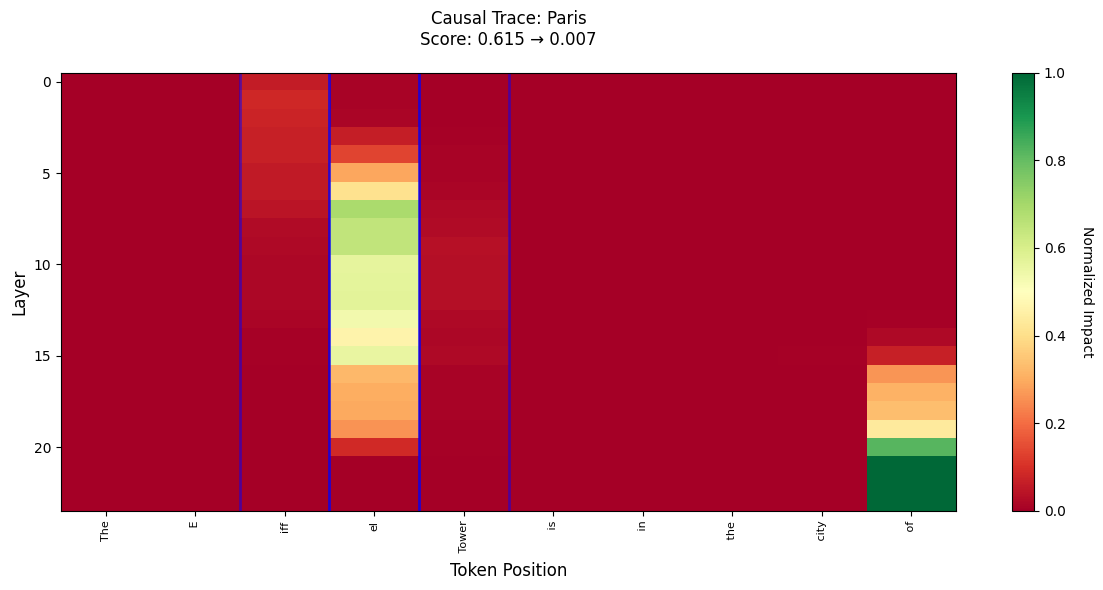

In [9]:
prompt = "The Eiffel Tower is in the city of"
subject = "Eiffel Tower"

# First, check what the model predicts
prediction = predict_token(mt, [prompt], return_p=True)
print(f"Model prediction: '{prediction[0][0]}' (prob: {prediction[1][0]:.3f})")

# Now run causal tracing
print("\nRunning causal tracing (this may take a few minutes)...")
result = plot_hidden_flow(
    mt,
    prompt,
    subject,
    samples=10,
    noise=noise_level,
    modelname=model_name
)

### Interpretation

The heatmap shows:
- **X-axis**: Token positions in the prompt
- **Y-axis**: Model layers (0 = earliest, higher = later)
- **Color**: Impact of restoring that state (green = high impact, red = low impact)
- **Blue lines**: Mark the subject tokens

**Key observations:**
1. Middle layers at subject token positions often show high impact
3. Later layers process this information for the final prediction

More examples


Prompt: Steve Jobs is the founder of
Subject: Steve Jobs
Prediction: ' Apple' (prob: 0.931)


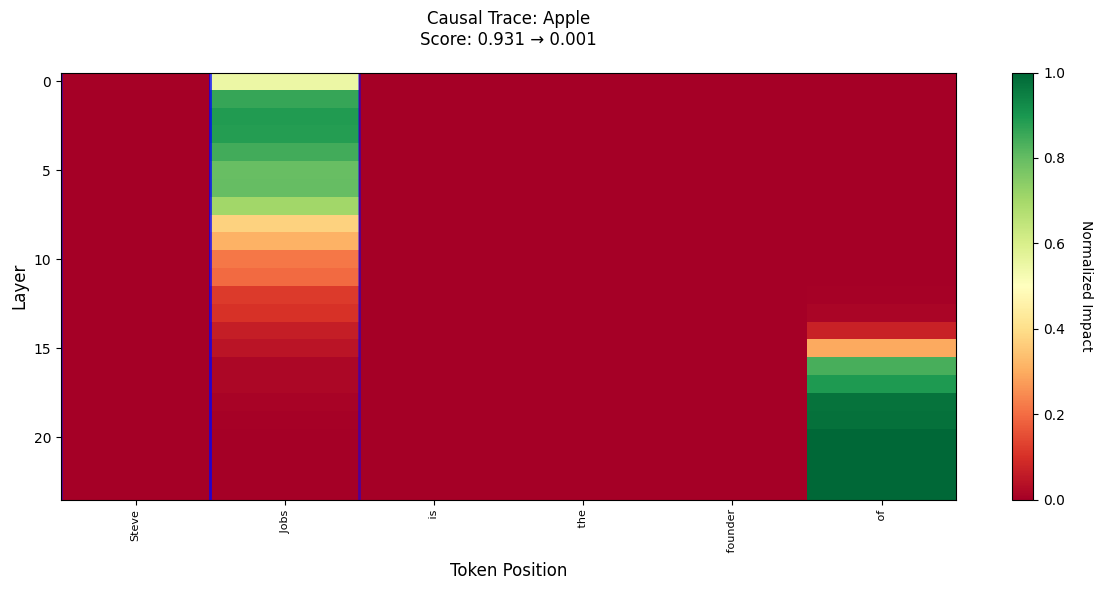


Prompt: The Mona Lisa was painted by
Subject: Mona Lisa
Prediction: ' Leonardo' (prob: 0.091)


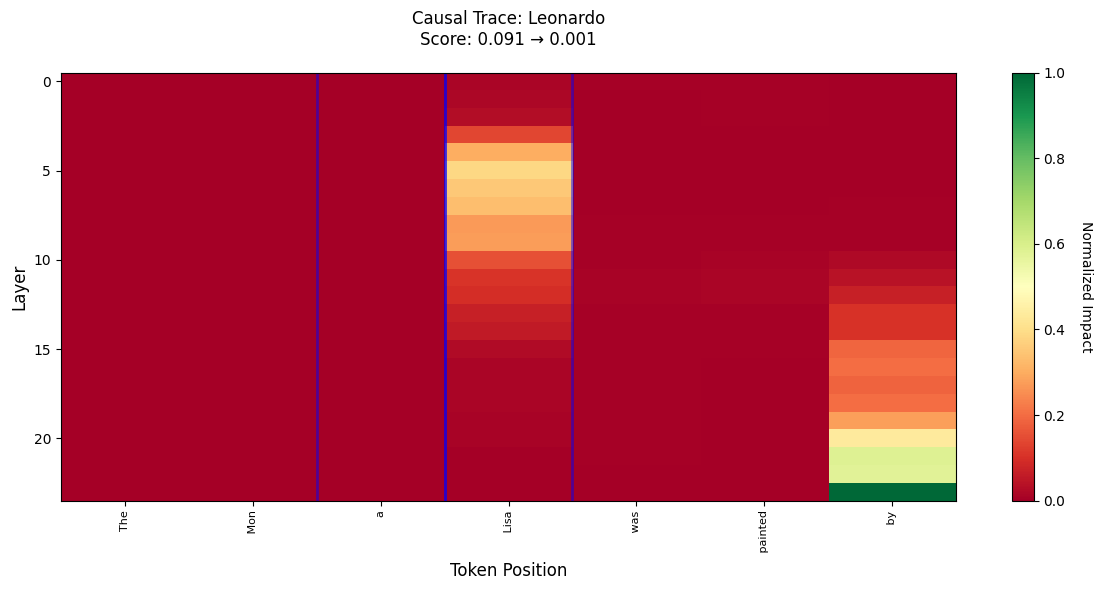

In [10]:
facts = [
    {
        "prompt": "Steve Jobs is the founder of",
        "subject": "Steve Jobs"
    },
    {
        "prompt": "The Mona Lisa was painted by",
        "subject": "Mona Lisa"
    },
]

for fact in facts:
    print(f"\n{'='*60}")
    print(f"Prompt: {fact['prompt']}")
    print(f"Subject: {fact['subject']}")
    print('='*60)
    
    # Predict
    pred = predict_token(mt, [fact['prompt']], return_p=True)
    print(f"Prediction: '{pred[0][0]}' (prob: {pred[1][0]:.3f})")
    
    # Trace
    result = plot_hidden_flow(
        mt,
        fact['prompt'],
        fact['subject'],
        samples=10,
        noise=noise_level,
        modelname=model_name
    )

## Comparing Components: MLP vs Attention

Trace MLP and attention blocks separately to see their different roles.

Tracing all components (residual, MLP, attention)...
This will generate 3 heatmaps showing different aspects of information flow.


Tracing residual...


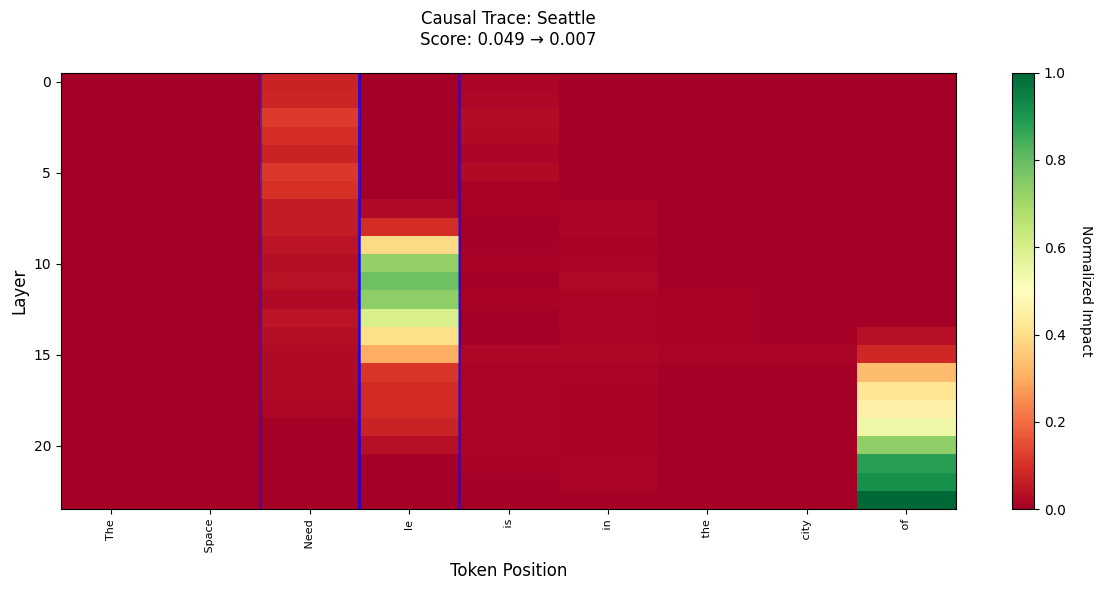


Tracing mlp...


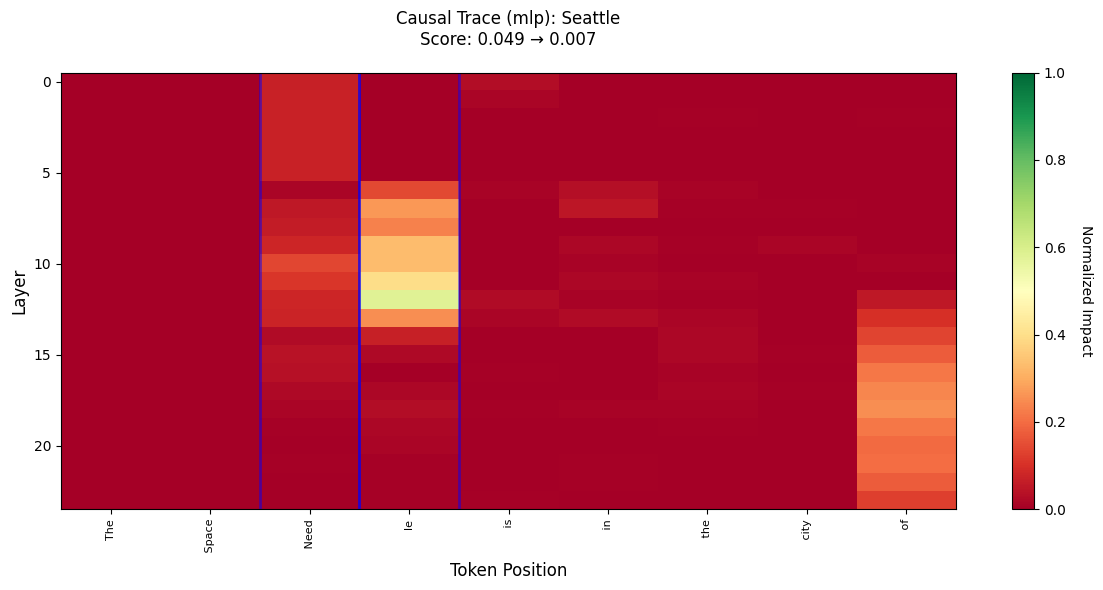


Tracing attn...


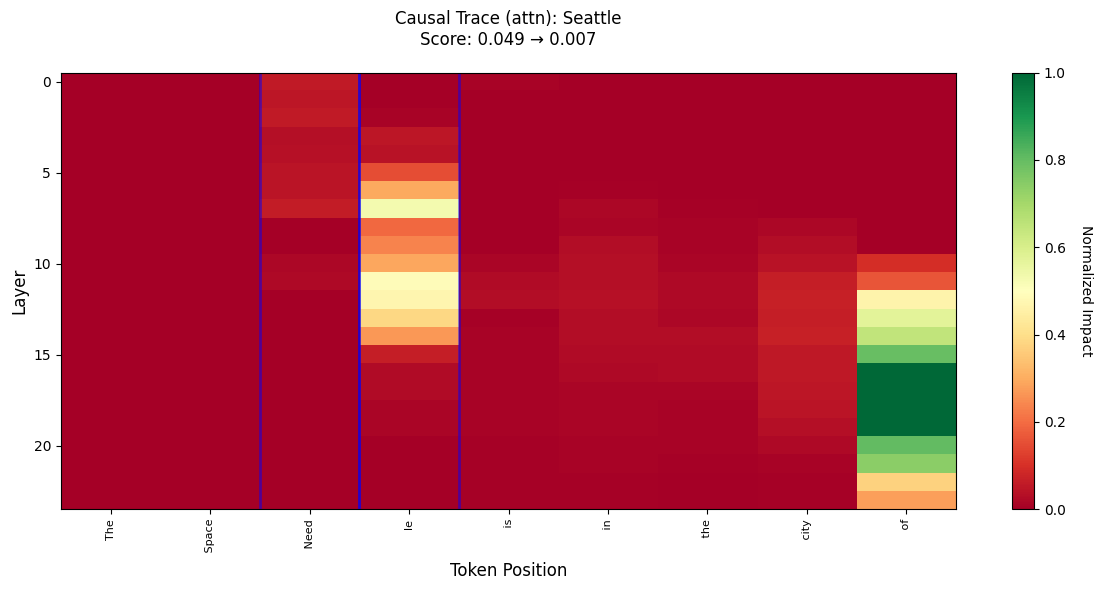

In [11]:
prompt = "The Space Needle is in the city of"
subject = "Space Needle"

print("Tracing all components (residual, MLP, attention)...")
print("This will generate 3 heatmaps showing different aspects of information flow.\n")

results = plot_all_flow(
    mt,
    prompt,
    subject,
    noise=noise_level,
    modelname=model_name
)

### Observations

**Residual Stream (first plot):**
- Shows the total effect of restoring hidden states
- Captures information flowing through the entire residual connection
- Typically shows the strongest signal

**MLP Blocks (second plot):**
- MLPs are thought to act as "key-value memories"
- Often show concentrated impact in middle layers
- Store factual knowledge in their parameters

**Attention Blocks (third plot):**
- Attention moves information between token positions
- Usually shows more distributed patterns
- Helps route information to where it's needed

### References
Locating and Editing Factual Associations in GPT (Meng et al., 2022) [Paper](https://arxiv.org/abs/2202.05262) | [Code](https://github.com/kmeng01/rome) | [Demo](https://colab.research.google.com/github/kmeng01/rome/blob/main/notebooks/causal_trace.ipynb)